In [83]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns
!pip freeze > requirements.txt

In [3]:
def load_gml(file_path):
    df = {}
    edges = []
    is_edge = False
    edges = []
    with open(file_path, 'r', encoding='utf-8') as f:
        lines = f.readlines()
        for line in lines:
            if(not is_edge):
                if('id' in line):
                    try:
                        id = int(line.split('id ')[1])
                        df[id] = ''
                    except:
                        continue
                if('value' in line):
                    try:
                        df[id] = int(line.split('value ')[1])
                    except:
                        continue
            else:
                if('source' in line):
                    try:
                        id = int(line.split('source ')[1])
                        aux = [0]*2
                        aux[0]= id
                    except:
                        continue
                if('target' in line):
                    try:
                        id = int(line.split('target ')[1])
                        aux[1]= id
                        edges.append(aux)
                    except:
                        continue
            if('edge ' in line):
                is_edge = True
    G = nx.DiGraph()
    G.add_edges_from(edges)
    for no, peso in df.items():
        G.add_node(no, weight=peso)
    return G

In [4]:
def apagar_nos_com_grau_zero(grafo):
    """
    Remove todos os nós com grau zero de um grafo.
    
    Parâmetros:
    - grafo: um grafo do networkx.
    
    Retorna:
    - O grafo sem os nós com grau zero.
    """
    # Identifica os nós com grau zero
    nos_grau_zero = [no for no, grau in grafo.degree() if grau == 0]
    
    # Remove os nós com grau zero
    grafo.remove_nodes_from(nos_grau_zero)
    
    return grafo

In [5]:
def calcular_graus_por_categoria(grafo, categoria):
    """
    Calcula o grau de entrada (in-degree) e o grau de saída (out-degree) para nós de uma categoria específica.
    
    Parâmetros:
    - grafo: um grafo direcionado (DiGraph) do networkx.
    - categoria: o valor do peso da categoria (0 ou 1).
    
    Retorna:
    - Um dicionário com o nó como chave e uma tupla (in-degree, out-degree) como valor.
    """
    graus_in = []
    graus_out = []
    
    # Itera sobre todos os nós no grafo
    for no in grafo.nodes(data=True):
        id_no = no[0]
        peso_no = no[1].get('weight', None)  # Pega o peso do nó
        
        # Verifica se o nó pertence à categoria especificada
        if peso_no == categoria:
            # Calcula o in-degree e o out-degree do nó
            in_degree = grafo.in_degree(id_no)
            out_degree = grafo.out_degree(id_no)
            
            # Armazena os graus de entrada e saída no dicionário
            graus_in.append(in_degree)
            graus_out.append(out_degree)
    
    return np.array(graus_in),np.array(graus_out)

In [6]:
def histogram(x):
    arr = np.arange(1,np.max(x))
    hist = np.zeros(len(arr))
    for i in x:
        for j in range(len(arr)):
            if(i < arr[j]):
                hist[j] += 1
                break
    arr = arr[hist!=0]
    hist = hist[hist!=0]
    return arr,hist

In [8]:
file_path = './polblogs/polblogs.gml'
G = load_gml(file_path)
G = apagar_nos_com_grau_zero(G)

In [12]:
def contar_ligacoes_in_por_categoria(grafo):
    """
    Cria um vetor onde cada coluna representa o número de ligações de entrada 
    que o nó tem com cada categoria de nós (peso 0 ou peso 1).
    
    Parâmetros:
    - grafo: Um grafo direcionado (DiGraph) do networkx onde cada nó tem peso 0 ou 1.
    
    Retorna:
    - Um dicionário onde a chave é o nó e o valor é uma tupla (ligacoes_com_peso_0, ligacoes_com_peso_1).
    """
    resultado = {}
    
    # Itera sobre todos os nós no grafo
    for no in grafo.nodes:
        ligacoes_com_peso_0 = 0
        ligacoes_com_peso_1 = 0
        
        # Pega os nós que têm arestas direcionadas para o nó atual (in-degree)
        nos_de_entrada = grafo.predecessors(no)
        
        # Conta quantas ligações de entrada vêm de nós com peso 0 ou 1
        for predecessor in nos_de_entrada:
            peso_predecessor = grafo.nodes[predecessor].get('weight', None)
            if peso_predecessor == 0:
                ligacoes_com_peso_0 += 1
            elif peso_predecessor == 1:
                ligacoes_com_peso_1 += 1
        
        # Armazena o resultado no dicionário
        resultado[no] = (ligacoes_com_peso_0, ligacoes_com_peso_1)
    
    return np.array(list(resultado.values()))

In [69]:
def generate_distribution_byfaixas(contagem,faixas):

    graus = np.sum(contagem,axis = 1)
    contagem = contagem[graus>0]
    faixas = faixas[graus>0]
    graus = graus[graus>0]
    B = contagem/(np.sum(contagem,axis = 1)[:, np.newaxis])
    B = [np.mean(B[faixas == i,:],axis = 0) for i in np.unique(faixas)]
    return B


In [67]:
df = contar_ligacoes_in_por_categoria(G)
categorias = np.array([G.nodes[i]['weight'] for i in G.nodes])

In [70]:
Matrix = generate_distribution_byfaixas(df,categorias)

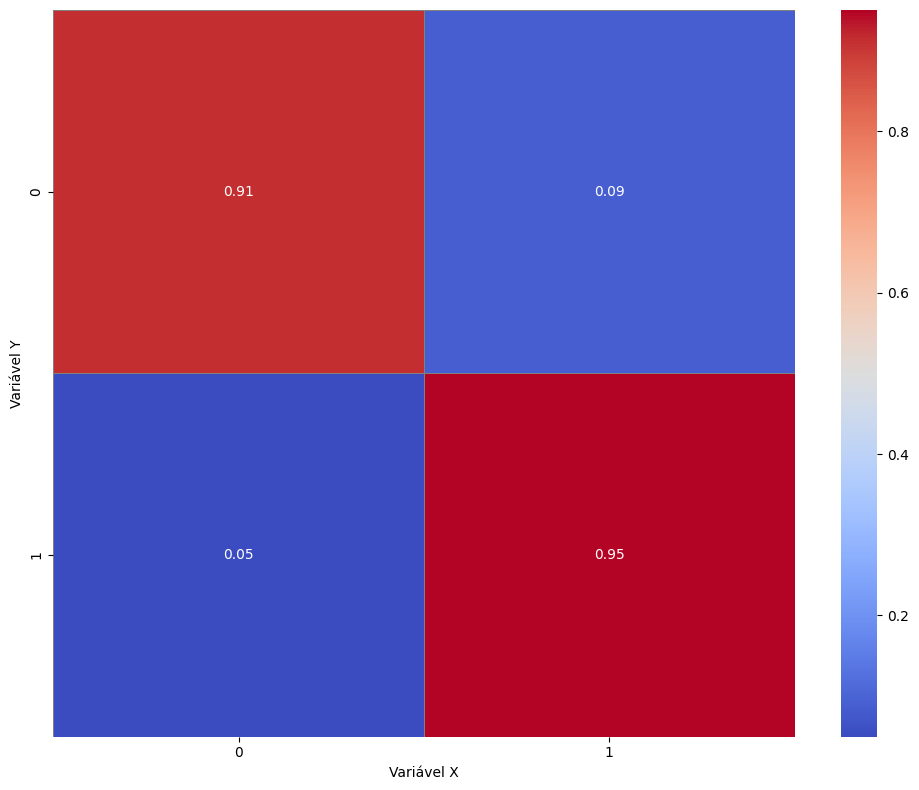

In [136]:
plt.figure(figsize=(10, 8))

heatmap = sns.heatmap(Matrix, 
                      annot=True,          # Adiciona os valores em cada célula
                      fmt=".2f",           # Formato dos números exibidos
                      cmap="coolwarm",      # Paleta de cores que vai do azul ao vermelho
                      #cbar_kws={'label': 'Escala de valores'},  # Legenda da barra de cores
                      linewidths=0.5,       # Largura das linhas entre as células
                      linecolor='gray')     # Cor das linhas

# Título e rótulos
plt.xlabel("Variável X")
plt.ylabel("Variável Y")

# Ajustes finais
plt.tight_layout()
np.savetxt('./input/multi_probability.txt',Matrix,fmt = '%f')
# Exibir o gráfico
plt.show()

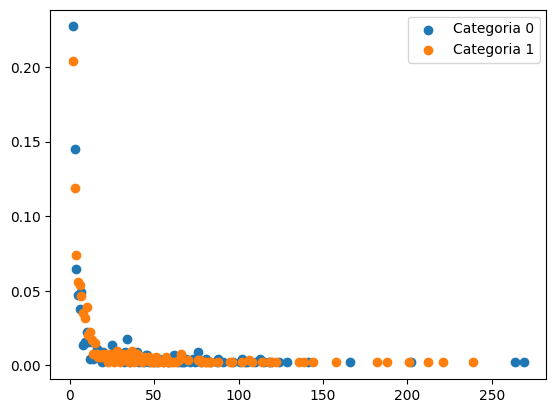

In [93]:
gin,gout = calcular_graus_por_categoria(G,0)
arr,hist = histogram(gin[gin > 0])
plt.scatter(arr,hist/np.sum(hist),label = 'Categoria 0')
gin,gout = calcular_graus_por_categoria(G,1)
arr,hist = histogram(gin[gin > 0])
plt.scatter(arr,hist/np.sum(hist),label = 'Categoria 1')
#arr,hist = histogram(gout)
#plt.scatter(arr,hist,label = 'Degree out')
plt.legend()
plt.show()

In [132]:
gin_0,_ = calcular_graus_por_categoria(G,0)
gin_1,_ = calcular_graus_por_categoria(G,1)

gin_0,p0 = histogram(gin_0[gin_0 > 0])
p0 = p0/np.sum(p0)
gin_1,p1 = histogram(gin_1[gin_1 > 0])
p1 = p1/np.sum(p1)

m = np.max([np.max(gin_0),np.max(gin_1)])
arr = np.arange(1,m+1)
prob = np.ones(len(arr))*-1
p0 = np.cumsum(p0)
for i,p in zip(gin_0,p0):
    prob[i-1] = p
P = np.array([arr,prob]).T
np.savetxt('./input/distribution_0.txt',P,fmt = "%d %f")


prob = np.ones(len(arr))*-1
p1 = np.cumsum(p1)
for i,p in zip(gin_0,p1):
    prob[i-1] = p
P = np.array([arr,prob]).T
np.savetxt('./input/distribution_1.txt',P,fmt = "%d %f")

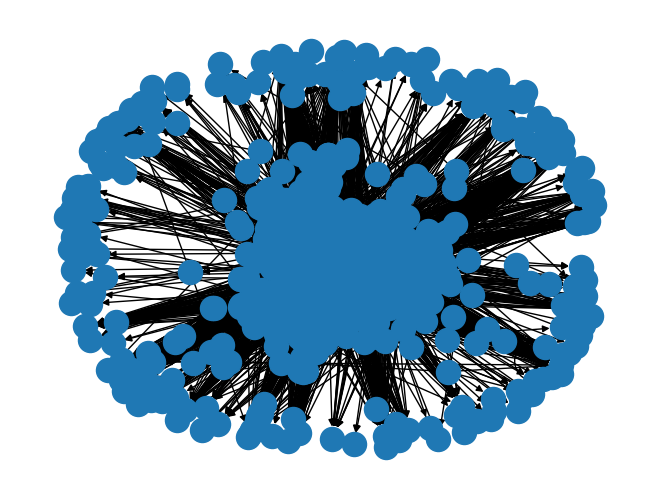

In [89]:
nx.draw(G)